In [124]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
from transformers import pipeline, AutoTokenizer
from trl import AutoModelForCausalLMWithValueHead
from datasets import load_dataset
from trl.core import LengthSampler


In [125]:
def build_dataset(model_name, dataset_name="stanfordnlp/imdb",input_min_text_length=2,input_max_text_length=8,):
            """
            Build dataset for training. This builds the dataset from `load_dataset`, one should
            customize this function to train the model on its own dataset.

            Args:
                dataset_name (`str`):
                    The name of the dataset to be loaded.

            Returns:
                dataloader (`torch.utils.data.DataLoader`):
                    The dataloader for the dataset.
            """
            tokenizer = AutoTokenizer.from_pretrained(model_name)
            tokenizer.pad_token = tokenizer.eos_token
            # load imdb with datasets
            ds = load_dataset(dataset_name, split="train")
            ds = ds.rename_columns({"text": "review"})
            ds = ds.filter(lambda x: len(x["review"]) > 200, batched=False)

            input_size = LengthSampler(input_min_text_length, input_max_text_length)

            def tokenize(sample):
                sample["input_ids"] = tokenizer.encode(sample["review"])[: input_size()]
                sample["query"] = tokenizer.decode(sample["input_ids"])
                return sample

            ds = ds.map(tokenize, batched=False)
            ds.set_format(type="torch")
            return ds

In [126]:
mean_results = {}
median_results = {}

#lambdas = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
base_gpt2_model_name = "lvwerra/gpt2-imdb"
tokenizer = AutoTokenizer.from_pretrained(base_gpt2_model_name)

device = 0 if torch.cuda.is_available() else "cpu" 
sent_kwargs = {"top_k": None, "function_to_apply": "none", "batch_size": 16}
gen_kwargs = {
    "min_length": -1,
    "top_k": 0.0,
    "top_p": 1.0,
    "do_sample": True,
    "pad_token_id": tokenizer.eos_token_id,
}

In [127]:
dataset = build_dataset(base_gpt2_model_name)
dataset

Dataset({
    features: ['review', 'label', 'input_ids', 'query'],
    num_rows: 24895
})

In [129]:
import os
folder_path = "/Users/carolinezhang/downloads/all_models"
model_names = []
model_names = [entry.name for entry in os.scandir(folder_path) if entry.is_dir()]
model_names

['gpt2-imdb-0.4pos-0.6neg',
 'gpt2-imdb-pos-neg-interpolated-fixed0.5',
 'gpt2-imdb-pos-neg-interpolated-fixed0.2',
 'gpt2-imdb-min-weights-model',
 'gpt2-imdb-0.3pos-0.7neg',
 'gpt2-imdb-0.6pos-0.4neg',
 'gpt2-imdb-pos-neg-interpolated-fixed0.3',
 'gpt2-imdb-pos-neg-interpolated-fixed0.4',
 'gpt2-imdb-max-weights-model',
 'gpt2-imdb-0.1pos-0.9neg',
 'gpt2-imdb-pos-neg-interpolated-fixed0',
 'gpt2-imdb-0.5pos-0.5neg',
 'gpt2-imdb-pos-neg-interpolated-fixed1',
 'gpt2-imdb-pos-neg-interpolated-fixed0.1',
 'gpt2-imdb-pos-neg-interpolated-fixed0.6',
 'gpt2-imdb-pos-neg-interpolated-fixed0.8',
 'gpt2-imdb-pos-neg-interpolated-fixed0.9',
 'gpt2-imdb-pos-neg-interpolated-fixed0.7',
 'gpt2-imdb-0.7pos-0.3neg',
 'gpt2-imdb-0.9pos-0.1neg']

In [130]:
# LOCAL MODEL
#finetuned_model_name = "carolinezhang/gpt2-imdb-pos-v2"
#finetuned_model = AutoModelForCausalLMWithValueHead.from_pretrained("/Users/carolinezhang/downloads/interpolated_models/gpt2-imdb-pos-neg-interpolated-fixed0.9")
#print("###### \n ##### base model name = ", finetuned_model_name)
import os
folder_path = "/Users/carolinezhang/downloads/all_models"
model_names = []
model_names = [entry.name for entry in os.scandir(folder_path) if entry.is_dir()]

for model in model_names:
    finetuned_model_name = "/Users/carolinezhang/downloads/all_models/"+model
    finetuned_model = AutoModelForCausalLMWithValueHead.from_pretrained(finetuned_model_name)
            
    ### Model Inspection
    '''
    Let's inspect some examples from the IMDB dataset. 
    We can use ref_model to compare the finetuned model against the ref model before optimisation.
    '''
    #### get a batch from the dataset
    bs = 250
    game_data = dict()
    dataset.set_format("pandas")
    df_batch = dataset[:].sample(bs)
    game_data["query"] = df_batch["query"].tolist()
    query_tensors = df_batch["input_ids"].tolist()

    response_tensors = []
    output_min_length = 4
    output_max_length = 16
    output_length_sampler = LengthSampler(output_min_length, output_max_length)

    #### get response from model tuned using pos and neg weights
    for i in range(bs):
        query = torch.tensor(query_tensors[i]).to(device)

        gen_len = output_length_sampler()
        # Response from model tuned with a mix of negatively and positively finetuned models' weights
        query_response = finetuned_model.generate(
            query.unsqueeze(0), max_new_tokens=gen_len, **gen_kwargs
        ).squeeze()
        response_len = len(query_response) - len(query)
        response_tensors.append(query_response[-response_len:])

    #### decode responses
    game_data["response (finetuned)"] = [
        tokenizer.decode(response_tensors[i]) for i in range(bs)
    ]

    # queries = game_data['query']
    # finetuned_responses = game_data['response (finetuned)']

    # for i in range(bs):
    #     print("########################")
    #     print(f"Query = {queries[i]}")
    #     print(f"Finetuned response = {finetuned_responses[i]}")
    #     print("########################")

    #### sentiment analysis of query/response pairs before/after
    sentiment_pipe = pipeline(
        "sentiment-analysis", model="lvwerra/distilbert-imdb", device=device
    )

    # ##### Results of finetuned model
    texts = [q + r for q, r in zip(game_data["query"], game_data["response (finetuned)"])]
    pipe_outputs = sentiment_pipe(texts, **sent_kwargs)

    positive_scores = [
        item["score"]
        for output in pipe_outputs
        for item in output
        if item["label"] == "POSITIVE"
    ]

    negative_scores = [
        item["score"]
        for output in pipe_outputs
        for item in output
        if item["label"] == "NEGATIVE"
    ]
    game_data["positive rewards (finetuned)"] = positive_scores
    game_data["negative rewards (finetuned)"] = negative_scores


    # store results in a dataframe
    df_results = pd.DataFrame(game_data)
    df_results

    print("Mean for lambda: ")
    print(df_results[["positive rewards (finetuned)"]].mean())
    print(df_results[["negative rewards (finetuned)"]].mean())

    tup_mean = ( float(df_results["positive rewards (finetuned)"].mean()), float(df_results["negative rewards (finetuned)"].mean()) )

    print()
    print("Median for lambda :")
    print(df_results[["positive rewards (finetuned)"]].median())
    print(df_results[["negative rewards (finetuned)"]].median())

    tup_median = (float(df_results["positive rewards (finetuned)"].median()), float(df_results["negative rewards (finetuned)"].median()))

    mean_results[finetuned_model_name] = tup_mean
    median_results[finetuned_model_name] = tup_median


Some weights of the model checkpoint at /Users/carolinezhang/downloads/all_models/gpt2-imdb-0.4pos-0.6neg were not used when initializing GPT2LMHeadModel: ['v_head.summary.bias', 'v_head.summary.weight']
- This IS expected if you are initializing GPT2LMHeadModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing GPT2LMHeadModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu
Some weights of the model checkpoint at /Users/carolinezhang/downloads/all_models/gpt2-imdb-pos-neg-interpolated-fixed0.5 were not used when initializing GPT2LMHeadModel: ['v_head.summary.bias', 'v_head.summary.weight']
- This IS expected if you are initializing GPT2LMHeadModel from the checkpoint of a model

Mean for lambda: 
positive rewards (finetuned)   -0.26098
dtype: float64
negative rewards (finetuned)    0.129187
dtype: float64

Median for lambda :
positive rewards (finetuned)   -0.240961
dtype: float64
negative rewards (finetuned)    0.085772
dtype: float64


Device set to use cpu
Some weights of the model checkpoint at /Users/carolinezhang/downloads/all_models/gpt2-imdb-pos-neg-interpolated-fixed0.2 were not used when initializing GPT2LMHeadModel: ['v_head.summary.bias', 'v_head.summary.weight']
- This IS expected if you are initializing GPT2LMHeadModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing GPT2LMHeadModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Mean for lambda: 
positive rewards (finetuned)    0.657435
dtype: float64
negative rewards (finetuned)   -0.637712
dtype: float64

Median for lambda :
positive rewards (finetuned)    1.680683
dtype: float64
negative rewards (finetuned)   -1.46159
dtype: float64


Device set to use cpu
Some weights of the model checkpoint at /Users/carolinezhang/downloads/all_models/gpt2-imdb-min-weights-model were not used when initializing GPT2LMHeadModel: ['v_head.summary.bias', 'v_head.summary.weight']
- This IS expected if you are initializing GPT2LMHeadModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing GPT2LMHeadModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


...

Mean for lambda: 
positive rewards (finetuned)    1.938855
dtype: float64
negative rewards (finetuned)   -1.756341
dtype: float64

Median for lambda :
positive rewards (finetuned)    2.586496
dtype: float64
negative rewards (finetuned)   -2.307112
dtype: float64


Device set to use cpu
Some weights of the model checkpoint at /Users/carolinezhang/downloads/all_models/gpt2-imdb-0.9pos-0.1neg were not used when initializing GPT2LMHeadModel: ['v_head.summary.bias', 'v_head.summary.weight']
- This IS expected if you are initializing GPT2LMHeadModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing GPT2LMHeadModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Mean for lambda: 
positive rewards (finetuned)    1.736166
dtype: float64
negative rewards (finetuned)   -1.578925
dtype: float64

Median for lambda :
positive rewards (finetuned)    2.251731
dtype: float64
negative rewards (finetuned)   -2.000914
dtype: float64


Device set to use cpu


Mean for lambda: 
positive rewards (finetuned)    2.177286
dtype: float64
negative rewards (finetuned)   -1.963166
dtype: float64

Median for lambda :
positive rewards (finetuned)    2.629716
dtype: float64
negative rewards (finetuned)   -2.349559
dtype: float64


In [106]:
print("/Users/carolinezhang/downloads/all_models/"+model_names[0])
print(finetuned_model_name)



/Users/carolinezhang/downloads/all_models/gpt2-imdb-pos-neg-interpolated-fixed0.5
/Users/carolinezhang/downloads/all_models/gpt2-imdb-pos-neg-interpolated-fixed0.5


In [82]:
len(game_data.get("response (finetuned)"))

250

In [131]:
mean_results

{'/Users/carolinezhang/downloads/all_models/gpt2-imdb-0.4pos-0.6neg': (-0.26097966626472774,
  0.12918664978805464),
 '/Users/carolinezhang/downloads/all_models/gpt2-imdb-pos-neg-interpolated-fixed0.5': (0.6574351055920125,
  -0.6377122318837791),
 '/Users/carolinezhang/downloads/all_models/gpt2-imdb-pos-neg-interpolated-fixed0.2': (-2.0253369795680047,
  1.6929295440707355),
 '/Users/carolinezhang/downloads/all_models/gpt2-imdb-min-weights-model': (0.5284332971870899,
  -0.5318785859681666),
 '/Users/carolinezhang/downloads/all_models/gpt2-imdb-0.3pos-0.7neg': (-1.2739176025986672,
  1.0141311234273016),
 '/Users/carolinezhang/downloads/all_models/gpt2-imdb-0.6pos-0.4neg': (1.4132008229456843,
  -1.28865133972466),
 '/Users/carolinezhang/downloads/all_models/gpt2-imdb-pos-neg-interpolated-fixed0.3': (-1.5953877097964286,
  1.3247352614551782),
 '/Users/carolinezhang/downloads/all_models/gpt2-imdb-pos-neg-interpolated-fixed0.4': (-0.6184997679716907,
  0.4678528545340523),
 '/Users/car

In [59]:
mean_results = {}
mean_results["name"] = tup_mean

mean_results

{'name': (2.2070985978245736, -1.991108635812998)}

In [98]:
import os
folder_path = "/Users/carolinezhang/downloads/all_models"
model_names = []
model_names = [entry.name for entry in os.scandir(folder_path) if entry.is_dir()]
model_names

['gpt2-imdb-pos-neg-interpolated-fixed0.5',
 'gpt2-imdb-pos-neg-interpolated-fixed0.2',
 'gpt2-imdb-min-weights-model',
 'gpt2-imdb-pos-neg-interpolated-fixed0.3',
 'gpt2-imdb-pos-neg-interpolated-fixed0.4',
 'gpt2-imdb-max-weights-model',
 'gpt2-imdb-pos-neg-interpolated-fixed0',
 'gpt2-imdb-pos-neg-interpolated-fixed1',
 'gpt2-imdb-pos-neg-interpolated-fixed0.1',
 'gpt2-imdb-pos-neg-interpolated-fixed0.6',
 'gpt2-imdb-pos-neg-interpolated-fixed0.8',
 'gpt2-imdb-pos-neg-interpolated-fixed0.9',
 'gpt2-imdb-pos-neg-interpolated-fixed0.7']

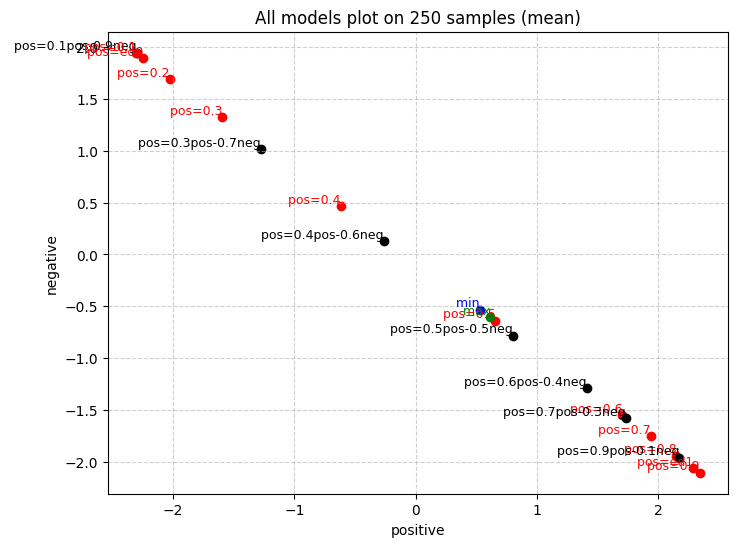

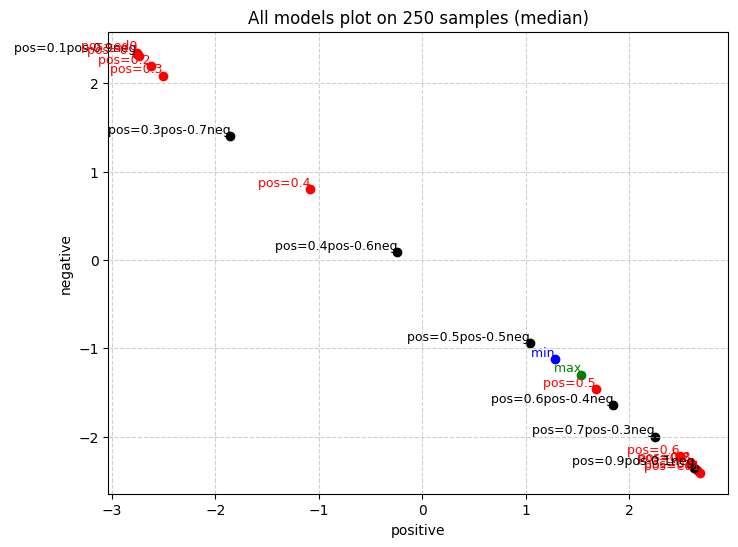

In [135]:
import matplotlib.pyplot as plt
import re
import numpy as np

def plot_points_with_labels(points_dict, regex_color_mapping, title):
    
    plt.figure(figsize=(8, 6))
    
    for label, (x, y) in points_dict.items():
        color = 'black' 
        for pattern, col in regex_color_mapping.items():
            if re.search(pattern, label):
                color = col
                break
        
        if "min" in label:
            display_label = "min"
        elif "max" in label:
            display_label = "max"
        elif "fixed" in label: 
            display_label = "pos="+label[-3:]
        else:
            display_label = "pos="+label[-13:]
        plt.scatter(x, y, color=color, label=label)
        plt.text(x, y, f' {display_label}', fontsize=9, verticalalignment='bottom', horizontalalignment='right', color=color)
    
    plt.xlabel("positive")
    plt.ylabel("negative")
    plt.title(title)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

data = mean_results
title = "All models plot on 250 samples (mean)"
regex_to_color = {
    r".*fixed.*": "red",    
    r".*min.*": "blue",   
    r".*max.*": "green"  
}

plot_points_with_labels(data, regex_to_color, title)

data = median_results
title = "All models plot on 250 samples (median)"
regex_to_color = {
    r".*fixed.*": "red",    
    r".*min.*": "blue",   
    r".*max.*": "green"  
}

plot_points_with_labels(data, regex_to_color, title)